In [2]:
# ============================================================
import os
import gc
import re
import math
import json
import random
from pathlib import Path
from contextlib import nullcontext

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)


PyTorch: 2.10.0+cpu


In [3]:
# ============================================================
DATASET_TAG = "desync100"       # "fixed", "desync50", or "desync100"
ASCAD_PATH_OVERRIDE = None      # example: "/kaggle/input/.../ASCAD_desync50.h5"

RUN_MODE = "standard"          # "debug", "standard", or "final"
RESUME = True

SEED = 42
TARGET_BYTE = 2                 # ASCAD target byte used in the uploaded TransNet code

# Architecture/training mode.
MODEL_FAMILY = "hdlstm"        # Hierarchical Desync LSTM
NORM_MODE = "global"           # "global", "none", or "trace"

# No heavy shift augmentation. The ASCAD desync files are already desynchronised.
# The successful HDT desync50 run used AUG_SHIFT = 0, so keep that first.
AUG_SHIFT = 0
AUG_NOISE_STD = 0.0
AUG_AMP_STD = 0.02
AUG_OFFSET_STD = 0.01

# Effective batch 256 by default. Lower TRAIN_BATCH_SIZE if OOM and increase GRAD_ACCUM_STEPS.
TRAIN_BATCH_SIZE = 128
GRAD_ACCUM_STEPS = 2
EFFECTIVE_BATCH_SIZE = TRAIN_BATCH_SIZE * GRAD_ACCUM_STEPS
EVAL_BATCH_SIZE = 128

# Dataloader workers: 0 is slower but stable in notebooks.
NUM_WORKERS = 0

if RUN_MODE == "debug":
    TRAIN_STEPS = 1000
    SAVE_EVERY_STEPS = 500
    LR_DECAY_STEPS = 12000 if DATASET_TAG != "desync100" else 16000
    N_RANK_REPEATS = 5
    ATTACK_TRACES_FOR_GE = 3000
elif RUN_MODE == "standard":
    TRAIN_STEPS = 20000 if DATASET_TAG != "desync100" else 80000
    SAVE_EVERY_STEPS = 2000
    LR_DECAY_STEPS = 100000
    N_RANK_REPEATS = 30
    ATTACK_TRACES_FOR_GE = 5000
elif RUN_MODE == "final":
    TRAIN_STEPS = 24000 if DATASET_TAG != "desync100" else 50000
    SAVE_EVERY_STEPS = 4000
    LR_DECAY_STEPS = TRAIN_STEPS
    N_RANK_REPEATS = 100
    ATTACK_TRACES_FOR_GE = 10000
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

# Optimisation.
LR = 8e-4
MIN_LR_RATIO = 0.03
WARMUP_STEPS = 500 if RUN_MODE != "debug" else 100
WEIGHT_DECAY = 2e-4
GRAD_CLIP = 1.0
USE_AMP_REQUESTED = True

# Model dimensions.
D_MODEL = 128
LSTM_HIDDEN = D_MODEL // 2       # bidirectional output is 2 * LSTM_HIDDEN = D_MODEL
D_FF = 384
DROPOUT = 0.10
WINDOW_SIZE = 50
HIGHRES_WINDOW_LSTM_BLOCKS = 2
MID_WINDOW_LSTM_BLOCKS = 1
GLOBAL_LSTM_BLOCKS = 2
POOL_QUERIES = 4

# Auxiliary leakage heads. The final attack still uses the 256-class logits.
HW_AUX_WEIGHT = 0.20
BIT_AUX_WEIGHT = 0.05

MODEL_TAG = (
    f"hdlstm_{DATASET_TAG}_{RUN_MODE}_"
    f"d{D_MODEL}_h{LSTM_HIDDEN}_w{WINDOW_SIZE}_bs{TRAIN_BATCH_SIZE}x{GRAD_ACCUM_STEPS}_"
    f"norm-{NORM_MODE}_aug{AUG_SHIFT}"
)

print("DATASET_TAG:", DATASET_TAG)
print("RUN_MODE:", RUN_MODE)
print("MODEL_TAG:", MODEL_TAG)
print("TRAIN_STEPS:", TRAIN_STEPS)
print("SAVE_EVERY_STEPS:", SAVE_EVERY_STEPS)
print("LR_DECAY_STEPS:", LR_DECAY_STEPS)
print("TRAIN_BATCH_SIZE:", TRAIN_BATCH_SIZE)
print("GRAD_ACCUM_STEPS:", GRAD_ACCUM_STEPS)
print("EFFECTIVE_BATCH_SIZE:", EFFECTIVE_BATCH_SIZE)
print("NORM_MODE:", NORM_MODE)
print("AUG_SHIFT:", AUG_SHIFT)
print("USE_AMP_REQUESTED:", USE_AMP_REQUESTED)
print("RESUME:", RESUME)


DATASET_TAG: desync100
RUN_MODE: standard
MODEL_TAG: hdlstm_desync100_standard_d128_h64_w50_bs128x2_norm-global_aug0
TRAIN_STEPS: 80000
SAVE_EVERY_STEPS: 2000
LR_DECAY_STEPS: 100000
TRAIN_BATCH_SIZE: 128
GRAD_ACCUM_STEPS: 2
EFFECTIVE_BATCH_SIZE: 256
NORM_MODE: global
AUG_SHIFT: 0
USE_AMP_REQUESTED: True
RESUME: True


In [4]:
# ============================================================
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = bool(USE_AMP_REQUESTED and torch.cuda.is_available())
AMP_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)
print("USE_AMP:", USE_AMP)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory GB:", torch.cuda.get_device_properties(0).total_memory / 1024**3)


DEVICE: cpu
USE_AMP: False


In [5]:
# ============================================================
SBOX = np.array([
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76,
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0,
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15,
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75,
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84,
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf,
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8,
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2,
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73,
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb,
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79,
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08,
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a,
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e,
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf,
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16
], dtype=np.uint8)

HW_TABLE = np.array([bin(i).count("1") for i in range(256)], dtype=np.int64)
BIT_TABLE = np.array([[(i >> b) & 1 for b in range(8)] for i in range(256)], dtype=np.float32)

print("SBOX length:", len(SBOX))


SBOX length: 256


In [6]:
# ============================================================
def normalize_path_text(path):
    return str(path).lower().replace("_", "").replace("-", "").replace(" ", "")


def inspect_h5_candidate(path):
    try:
        with h5py.File(path, "r") as f:
            if "Profiling_traces" not in f or "Attack_traces" not in f:
                return None
            if "traces" not in f["Profiling_traces"] or "labels" not in f["Profiling_traces"]:
                return None
            if "traces" not in f["Attack_traces"] or "labels" not in f["Attack_traces"]:
                return None
            return {
                "path": str(path),
                "prof_shape": tuple(f["Profiling_traces/traces"].shape),
                "atk_shape": tuple(f["Attack_traces/traces"].shape),
                "has_meta": "metadata" in f["Profiling_traces"] and "metadata" in f["Attack_traces"],
            }
    except Exception:
        return None


def choose_ascad_path():
    if ASCAD_PATH_OVERRIDE is not None:
        path = Path(ASCAD_PATH_OVERRIDE)
        if not path.exists():
            raise FileNotFoundError(path)
        return str(path)

    search_roots = [Path("/kaggle/input"), Path("/mnt/data"), Path(".")]
    h5_files = []
    for root in search_roots:
        if root.exists():
            h5_files.extend(list(root.rglob("*.h5")))

    if len(h5_files) == 0:
        raise FileNotFoundError("No .h5 files found. Set ASCAD_PATH_OVERRIDE.")

    if DATASET_TAG == "fixed":
        wanted = [p for p in h5_files if "desync" not in normalize_path_text(p)]
    else:
        wanted = [p for p in h5_files if DATASET_TAG.lower() in normalize_path_text(p)]

    candidates = []
    for p in wanted:
        info = inspect_h5_candidate(p)
        if info is not None:
            candidates.append(info)

    if len(candidates) == 0:
        print("Found H5 files:")
        for p in h5_files:
            print(" -", p)
        raise FileNotFoundError(f"No ASCAD-like H5 matched DATASET_TAG={DATASET_TAG}")

    # Prefer canonical 50000 x 700 / 10000 x 700 files.
    def score(c):
        s = 0
        if c["prof_shape"] == (50000, 700): s -= 100
        if c["atk_shape"] == (10000, 700): s -= 100
        if c["has_meta"]: s -= 20
        return s

    candidates = sorted(candidates, key=score)
    print("Matching candidates:")
    for c in candidates:
        print(c)
    return candidates[0]["path"]


ASCAD_PATH = choose_ascad_path()
print("Using ASCAD_PATH:", ASCAD_PATH)

with h5py.File(ASCAD_PATH, "r") as f:
    X_prof = f["Profiling_traces/traces"][:].astype(np.float32)
    y_prof = f["Profiling_traces/labels"][:].astype(np.int64)
    meta_prof = f["Profiling_traces/metadata"][:]

    X_attack = f["Attack_traces/traces"][:].astype(np.float32)
    y_attack = f["Attack_traces/labels"][:].astype(np.int64)
    meta_attack = f["Attack_traces/metadata"][:]

print("X_prof:", X_prof.shape, X_prof.dtype, X_prof.min(), X_prof.max(), X_prof.mean(), X_prof.std())
print("X_attack:", X_attack.shape, X_attack.dtype, X_attack.min(), X_attack.max(), X_attack.mean(), X_attack.std())
print("y_prof:", y_prof.shape, "unique:", len(np.unique(y_prof)))
print("metadata fields:", meta_prof.dtype.names)


Matching candidates:
{'path': '/kaggle/input/datasets/govindgopa/ascad-dataset/ASCAD_desync100.h5', 'prof_shape': (50000, 700), 'atk_shape': (10000, 700), 'has_meta': True}
Using ASCAD_PATH: /kaggle/input/datasets/govindgopa/ascad-dataset/ASCAD_desync100.h5
X_prof: (50000, 700) float32 -66.0 47.0 -11.099548 26.114227
X_attack: (10000, 700) float32 -67.0 46.0 -11.061205 26.117954
y_prof: (50000,) unique: 256
metadata fields: ('plaintext', 'ciphertext', 'key', 'masks', 'desync')


In [7]:
# ============================================================
prof_plain = meta_prof["plaintext"][:, TARGET_BYTE].astype(np.uint8)
prof_key = meta_prof["key"][:, TARGET_BYTE].astype(np.uint8)
attack_plain = meta_attack["plaintext"][:, TARGET_BYTE].astype(np.uint8)
attack_key = meta_attack["key"][:, TARGET_BYTE].astype(np.uint8)

prof_expected = SBOX[np.bitwise_xor(prof_plain, prof_key)].astype(np.int64)
attack_expected = SBOX[np.bitwise_xor(attack_plain, attack_key)].astype(np.int64)

prof_match = float(np.mean(prof_expected == y_prof))
attack_match = float(np.mean(attack_expected == y_attack))
ATTACK_TRUE_KEY = int(attack_key[0])
attack_key_constant = bool(np.all(attack_key == ATTACK_TRUE_KEY))

print("Profiling label match:", prof_match)
print("Attack label match:", attack_match)
print("Attack true key:", ATTACK_TRUE_KEY)
print("Attack key constant:", attack_key_constant)

if prof_match < 0.999 or attack_match < 0.999:
    raise RuntimeError("Labels do not match SBOX[plaintext_byte xor key_byte]. Check TARGET_BYTE/dataset.")
if not attack_key_constant:
    raise RuntimeError("Attack target key is not constant; rank/GE would be invalid.")

label_counts = np.bincount(y_prof, minlength=256)
print("Label count min/max/mean:", label_counts.min(), label_counts.max(), label_counts.mean())
print("Random CE ln(256):", np.log(256.0))
print("Random accuracy:", 1/256)


Profiling label match: 1.0
Attack label match: 1.0
Attack true key: 224
Attack key constant: True
Label count min/max/mean: 154 244 195.3125
Random CE ln(256): 5.545177444479562
Random accuracy: 0.00390625


In [8]:
# ============================================================
if NORM_MODE == "global":
    norm_mean = np.array([X_prof.mean()], dtype=np.float32)
    norm_std = np.array([max(X_prof.std(), 1e-6)], dtype=np.float32)
elif NORM_MODE == "none":
    norm_mean = np.array([0.0], dtype=np.float32)
    norm_std = np.array([1.0], dtype=np.float32)
elif NORM_MODE == "trace":
    norm_mean = np.array([0.0], dtype=np.float32)
    norm_std = np.array([1.0], dtype=np.float32)
else:
    raise ValueError(f"Unknown NORM_MODE: {NORM_MODE}")

print("norm_mean:", norm_mean, "norm_std:", norm_std)


class ASCADTraceDataset(Dataset):
    def __init__(self, traces, labels, train=False):
        self.traces = traces.astype(np.float32)
        self.labels = labels.astype(np.int64)
        self.train = bool(train)

    def __len__(self):
        return len(self.traces)

    @staticmethod
    def shift_zero(x, shift):
        if shift == 0:
            return x
        y = np.zeros_like(x)
        if shift > 0:
            y[shift:] = x[:-shift]
        else:
            y[:shift] = x[-shift:]
        return y

    def normalise(self, x):
        if NORM_MODE == "global":
            x = (x - norm_mean[0]) / norm_std[0]
        elif NORM_MODE == "trace":
            x = (x - x.mean()) / max(x.std(), 1e-6)
        return x

    def __getitem__(self, idx):
        x = self.traces[idx].astype(np.float32)
        x = self.normalise(x)

        if self.train:
            if AUG_SHIFT > 0:
                shift = np.random.randint(-AUG_SHIFT, AUG_SHIFT + 1)
                x = self.shift_zero(x, shift)
            if AUG_AMP_STD > 0:
                x = x * np.float32(1.0 + np.random.normal(0.0, AUG_AMP_STD))
            if AUG_OFFSET_STD > 0:
                x = x + np.float32(np.random.normal(0.0, AUG_OFFSET_STD))
            if AUG_NOISE_STD > 0:
                x = x + np.random.normal(0.0, AUG_NOISE_STD, size=x.shape).astype(np.float32)

        y = int(self.labels[idx])
        hw = int(HW_TABLE[y])
        bits = BIT_TABLE[y]
        return (
            torch.from_numpy(x.astype(np.float32)),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(hw, dtype=torch.long),
            torch.from_numpy(bits.astype(np.float32)),
        )


train_ds = ASCADTraceDataset(X_prof, y_prof, train=True)
attack_ds = ASCADTraceDataset(X_attack, y_attack, train=False)

loader_kwargs = dict(
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

train_loader = DataLoader(
    train_ds,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    **loader_kwargs,
)

attack_loader = DataLoader(
    attack_ds,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)

print("Train batches:", len(train_loader))
print("Attack batches:", len(attack_loader))
xb, yb, hwb, bitb = next(iter(train_loader))
print("Batch:", xb.shape, yb.shape, hwb.shape, bitb.shape)
print("Batch trace mean/std:", float(xb.mean()), float(xb.std()))


norm_mean: [-11.099548] norm_std: [26.114227]
Train batches: 390
Attack batches: 79
Batch: torch.Size([128, 700]) torch.Size([128]) torch.Size([128]) torch.Size([128, 8])
Batch trace mean/std: 0.0029629652854055166 0.9994333386421204


In [9]:
# ============================================================
def stable_log_softmax_np(logits):
    z = logits.astype(np.float64)
    z = z - z.max(axis=1, keepdims=True)
    return z - np.log(np.exp(z).sum(axis=1, keepdims=True))


def rank_curve_from_log_probs(log_probs, plaintexts, true_key):
    key_scores = np.zeros(256, dtype=np.float64)
    ranks = np.zeros(len(log_probs), dtype=np.int64)
    key_candidates = np.arange(256, dtype=np.uint8)

    for i in range(len(log_probs)):
        pt = np.uint8(plaintexts[i])
        hyp_labels = SBOX[np.bitwise_xor(pt, key_candidates)]
        key_scores += log_probs[i, hyp_labels]
        true_score = key_scores[int(true_key)]
        ranks[i] = int(np.sum(key_scores > true_score))

    return ranks


def make_ge_indices(n_items, n_traces, n_repeats, seed):
    rng = np.random.default_rng(seed)
    n_traces = min(int(n_traces), int(n_items))
    return [rng.permutation(n_items)[:n_traces] for _ in range(int(n_repeats))]


def guessing_entropy_from_log_probs(log_probs, plaintexts, true_key, n_traces, n_repeats, seed):
    indices = make_ge_indices(len(log_probs), n_traces, n_repeats, seed)
    curves = []
    for idx in tqdm(indices, desc="GE repeats", leave=False):
        curve = rank_curve_from_log_probs(log_probs[idx], plaintexts[idx], true_key)
        curves.append(curve)
    curves = np.stack(curves, axis=0)
    return curves.mean(axis=0), curves.std(axis=0), curves


def metrics_from_ge(single_curve, ge_mean):
    if np.any(ge_mean < 1.0):
        t_ge = int(np.argmax(ge_mean < 1.0) + 1)
    else:
        t_ge = None
    if np.any(single_curve == 0):
        t_rank0 = int(np.argmax(single_curve == 0) + 1)
    else:
        t_rank0 = None
    return {
        "single_final_rank": int(single_curve[-1]),
        "single_min_rank": int(single_curve.min()),
        "single_traces_to_rank0": t_rank0,
        "ge_final": float(ge_mean[-1]),
        "ge_min": float(ge_mean.min()),
        "traces_to_ge_below_1": t_ge,
    }


In [10]:
# ============================================================
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        norm = x.pow(2).mean(dim=-1, keepdim=True).add(self.eps).sqrt()
        return x / norm * self.scale


class MultiScaleStem(nn.Module):
    def __init__(self, in_ch=3, d_model=128, dropout=0.05):
        super().__init__()
        branch = d_model // 4
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(in_ch, branch, kernel_size=k, padding=k // 2, bias=False),
                nn.GroupNorm(4, branch),
                nn.GELU(),
                nn.Conv1d(branch, branch, kernel_size=3, padding=1, bias=False),
                nn.GroupNorm(4, branch),
                nn.GELU(),
            )
            for k in [7, 15, 31, 51]
        ])
        self.fuse = nn.Sequential(
            nn.Conv1d(branch * 4, d_model, kernel_size=1, bias=False),
            nn.GroupNorm(8, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        x = torch.cat([b(x) for b in self.branches], dim=1)
        return self.fuse(x)


class ResidualDWConvBlock(nn.Module):
    def __init__(self, channels, kernel_size=15, dilation=1, dropout=0.05, expansion=2):
        super().__init__()
        padding = (kernel_size // 2) * dilation
        hidden = channels * expansion
        self.net = nn.Sequential(
            nn.GroupNorm(8, channels),
            nn.Conv1d(channels, hidden, kernel_size=1, bias=False),
            nn.GELU(),
            nn.Conv1d(hidden, hidden, kernel_size=kernel_size, padding=padding,
                      dilation=dilation, groups=hidden, bias=False),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1, bias=False),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return x + self.net(x)


class DownsampleTokens(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.conv = nn.Conv1d(dim, dim, kernel_size=5, stride=2, padding=2, bias=False)
        self.norm = nn.GroupNorm(8, dim)
        self.act = nn.GELU()
    def forward(self, x):
        # [B, L, D] -> [B, ceil(L/2), D]
        x = x.transpose(1, 2)
        x = self.act(self.norm(self.conv(x)))
        return x.transpose(1, 2)


class WindowBiLSTMBlock(nn.Module):
    """
    Local recurrent block analogous to the windowed-attention block in HDT.
    It models short temporal neighborhoods without forcing a single LSTM to scan
    all 700 samples before the convolutional front-end has stabilised the leakage.
    """
    def __init__(self, dim, hidden, window_size=50, dropout=0.10, shift=False):
        super().__init__()
        assert hidden * 2 == dim, "Use hidden = dim // 2 so BiLSTM output matches dim."
        self.dim = dim
        self.hidden = hidden
        self.window_size = int(window_size)
        self.shift = bool(shift)
        self.shift_size = self.window_size // 2 if self.shift else 0

        self.norm1 = RMSNorm(dim)
        self.lstm = nn.LSTM(
            input_size=dim,
            hidden_size=hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.drop = nn.Dropout(dropout)

        self.norm2 = RMSNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, 4 * dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * dim, dim),
            nn.Dropout(dropout),
        )

    def partition_windows(self, x):
        B, L, D = x.shape
        pad_len = (self.window_size - L % self.window_size) % self.window_size
        if pad_len > 0:
            x = F.pad(x, (0, 0, 0, pad_len))
        Lp = x.shape[1]
        x = x.view(B, Lp // self.window_size, self.window_size, D)
        x = x.reshape(B * (Lp // self.window_size), self.window_size, D)
        return x, L, Lp

    def merge_windows(self, xw, B, L, Lp):
        x = xw.view(B, Lp // self.window_size, self.window_size, self.dim)
        x = x.reshape(B, Lp, self.dim)
        return x[:, :L, :]

    def forward(self, x):
        B, L, D = x.shape
        residual = x
        y = self.norm1(x)

        if self.shift_size > 0 and L > self.window_size:
            y = torch.roll(y, shifts=-self.shift_size, dims=1)

        yw, orig_L, Lp = self.partition_windows(y)
        out, _ = self.lstm(yw)
        out = self.drop(out)
        out = self.merge_windows(out, B, orig_L, Lp)

        if self.shift_size > 0 and L > self.window_size:
            out = torch.roll(out, shifts=self.shift_size, dims=1)

        x = residual + out
        x = x + self.mlp(self.norm2(x))
        return x


class ResidualBiLSTMBlock(nn.Module):
    """
    Global recurrent block used only after two stages of convolutional feature
    extraction and downsampling. This avoids scanning raw samples directly.
    """
    def __init__(self, dim, hidden, dropout=0.10):
        super().__init__()
        assert hidden * 2 == dim
        self.norm1 = RMSNorm(dim)
        self.lstm = nn.LSTM(
            input_size=dim,
            hidden_size=hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.drop = nn.Dropout(dropout)
        self.norm2 = RMSNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, D_FF),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(D_FF, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        y = self.norm1(x)
        out, _ = self.lstm(y)
        x = x + self.drop(out)
        x = x + self.mlp(self.norm2(x))
        return x


class MultiQueryPool(nn.Module):
    def __init__(self, dim, n_queries=4):
        super().__init__()
        self.queries = nn.Parameter(torch.randn(n_queries, dim) * 0.02)
        self.norm = RMSNorm(dim)
    def forward(self, x):
        y = self.norm(x)
        scores = torch.einsum("bld,qd->bql", y, self.queries) / math.sqrt(y.shape[-1])
        weights = torch.softmax(scores.float(), dim=-1).to(x.dtype)
        pooled = torch.einsum("bql,bld->bqd", weights, x)
        return pooled.reshape(x.shape[0], -1)


class HierarchicalDesyncLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = MultiScaleStem(in_ch=3, d_model=D_MODEL, dropout=DROPOUT * 0.5)

        # Same successful HDT principle: preserve full temporal resolution early.
        self.high_conv = nn.Sequential(
            ResidualDWConvBlock(D_MODEL, kernel_size=7, dilation=1, dropout=DROPOUT * 0.5),
            ResidualDWConvBlock(D_MODEL, kernel_size=15, dilation=1, dropout=DROPOUT * 0.5),
            ResidualDWConvBlock(D_MODEL, kernel_size=15, dilation=2, dropout=DROPOUT * 0.5),
            ResidualDWConvBlock(D_MODEL, kernel_size=31, dilation=1, dropout=DROPOUT * 0.5),
        )

        # Local recurrent modelling before compression, in windows to keep it stable and memory-safe.
        self.high_lstm = nn.ModuleList([
            WindowBiLSTMBlock(D_MODEL, LSTM_HIDDEN, WINDOW_SIZE, DROPOUT, shift=(i % 2 == 1))
            for i in range(HIGHRES_WINDOW_LSTM_BLOCKS)
        ])

        self.down1 = DownsampleTokens(D_MODEL)   # 700 -> 350
        self.mid_conv = nn.Sequential(
            ResidualDWConvBlock(D_MODEL, kernel_size=15, dilation=1, dropout=DROPOUT * 0.5),
            ResidualDWConvBlock(D_MODEL, kernel_size=15, dilation=2, dropout=DROPOUT * 0.5),
        )
        self.mid_lstm = nn.ModuleList([
            WindowBiLSTMBlock(D_MODEL, LSTM_HIDDEN, WINDOW_SIZE, DROPOUT, shift=(i % 2 == 1))
            for i in range(MID_WINDOW_LSTM_BLOCKS)
        ])

        self.down2 = DownsampleTokens(D_MODEL)   # 350 -> 175
        self.global_lstm = nn.ModuleList([
            ResidualBiLSTMBlock(D_MODEL, LSTM_HIDDEN, DROPOUT)
            for _ in range(GLOBAL_LSTM_BLOCKS)
        ])

        self.pool = MultiQueryPool(D_MODEL, POOL_QUERIES)
        feature_dim = D_MODEL * (POOL_QUERIES + 3)  # query pool + mean/max/std
        self.feature_norm = nn.LayerNorm(feature_dim)
        self.shared_head = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(DROPOUT),
        )
        self.class_head = nn.Linear(256, 256)
        self.hw_head = nn.Linear(256, 9)
        self.bit_head = nn.Linear(256, 8)
        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="linear")
            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if "weight_ih" in name:
                        nn.init.xavier_uniform_(param)
                    elif "weight_hh" in name:
                        nn.init.orthogonal_(param)
                    elif "bias" in name:
                        nn.init.zeros_(param)

    def make_channels(self, traces):
        x = traces.unsqueeze(1)  # [B, 1, T]
        diff = torch.zeros_like(x)
        diff[:, :, 1:] = x[:, :, 1:] - x[:, :, :-1]
        smooth = F.avg_pool1d(x, kernel_size=5, stride=1, padding=2)
        return torch.cat([x, diff, smooth], dim=1)

    def forward(self, traces, return_aux=False):
        x = self.make_channels(traces)
        x = self.stem(x)
        x = self.high_conv(x)
        x = x.transpose(1, 2)  # [B, L, D]

        for block in self.high_lstm:
            x = block(x)

        x = self.down1(x)
        xc = x.transpose(1, 2)
        xc = self.mid_conv(xc)
        x = xc.transpose(1, 2)

        for block in self.mid_lstm:
            x = block(x)

        x = self.down2(x)

        for block in self.global_lstm:
            x = block(x)

        qpool = self.pool(x)
        mean = x.mean(dim=1)
        maxv = x.amax(dim=1)
        std = x.std(dim=1, unbiased=False)
        features = torch.cat([qpool, mean, maxv, std], dim=1)
        features = self.feature_norm(features)
        shared = self.shared_head(features)
        logits = self.class_head(shared)

        if return_aux:
            return {
                "logits": logits,
                "hw_logits": self.hw_head(shared),
                "bit_logits": self.bit_head(shared),
            }
        return logits


model = HierarchicalDesyncLSTM().to(DEVICE)
num_params = sum(p.numel() for p in model.parameters())
print("Parameters:", f"{num_params:,}")

with torch.no_grad():
    test_out = model(xb[:2].to(DEVICE), return_aux=True)
print("Logits:", test_out["logits"].shape, "HW:", test_out["hw_logits"].shape, "Bits:", test_out["bit_logits"].shape)


Parameters: 2,377,489
Logits: torch.Size([2, 256]) HW: torch.Size([2, 9]) Bits: torch.Size([2, 8])


In [11]:
# ============================================================
CKPT_DIR = Path(f"/kaggle/working/{MODEL_TAG}_ckpt") if Path("/kaggle/working").exists() else Path(f"/mnt/data/{MODEL_TAG}_ckpt")
RESULT_DIR = Path(f"/kaggle/working/{MODEL_TAG}_results") if Path("/kaggle/working").exists() else Path(f"/mnt/data/{MODEL_TAG}_results")
CKPT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
print("CKPT_DIR:", CKPT_DIR)
print("RESULT_DIR:", RESULT_DIR)

criterion_cls = nn.CrossEntropyLoss()
criterion_hw = nn.CrossEntropyLoss()
criterion_bits = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

class CosineLRSchedule:
    def __init__(self, max_lr, decay_steps, warmup_steps=0, min_lr_ratio=0.03):
        self.max_lr = float(max_lr)
        self.decay_steps = int(decay_steps)
        self.warmup_steps = int(warmup_steps)
        self.min_lr_ratio = float(min_lr_ratio)
    def __call__(self, step):
        step = int(step)
        if self.warmup_steps > 0 and step < self.warmup_steps:
            return self.max_lr * (step + 1) / max(1, self.warmup_steps)
        progress = min(1.0, (step - self.warmup_steps) / max(1, self.decay_steps - self.warmup_steps))
        cosine_decay = 0.5 * (1.0 + math.cos(math.pi * progress))
        decayed = (1.0 - self.min_lr_ratio) * cosine_decay + self.min_lr_ratio
        return self.max_lr * decayed

lr_schedule = CosineLRSchedule(LR, LR_DECAY_STEPS, WARMUP_STEPS, MIN_LR_RATIO)

try:
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

history = []
start_step = 0

def set_lr(step):
    lr = lr_schedule(step)
    for group in optimizer.param_groups:
        group["lr"] = lr
    return lr


def save_checkpoint(step, name="last.pt"):
    ckpt = {
        "step": int(step),
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scaler": scaler.state_dict(),
        "history": history,
        "config": {
            "MODEL_TAG": MODEL_TAG,
            "DATASET_TAG": DATASET_TAG,
            "RUN_MODE": RUN_MODE,
            "ASCAD_PATH": ASCAD_PATH,
            "TARGET_BYTE": TARGET_BYTE,
            "ATTACK_TRUE_KEY": ATTACK_TRUE_KEY,
            "TRAIN_STEPS": TRAIN_STEPS,
            "TRAIN_BATCH_SIZE": TRAIN_BATCH_SIZE,
            "GRAD_ACCUM_STEPS": GRAD_ACCUM_STEPS,
            "EFFECTIVE_BATCH_SIZE": EFFECTIVE_BATCH_SIZE,
            "NORM_MODE": NORM_MODE,
            "AUG_SHIFT": AUG_SHIFT,
            "LR": LR,
            "WEIGHT_DECAY": WEIGHT_DECAY,
            "D_MODEL": D_MODEL,
            "LSTM_HIDDEN": LSTM_HIDDEN,
            "WINDOW_SIZE": WINDOW_SIZE,
            "HIGHRES_WINDOW_LSTM_BLOCKS": HIGHRES_WINDOW_LSTM_BLOCKS,
            "MID_WINDOW_LSTM_BLOCKS": MID_WINDOW_LSTM_BLOCKS,
            "GLOBAL_LSTM_BLOCKS": GLOBAL_LSTM_BLOCKS,
            "HW_AUX_WEIGHT": HW_AUX_WEIGHT,
            "BIT_AUX_WEIGHT": BIT_AUX_WEIGHT,
            "num_params": num_params,
        },
    }
    torch.save(ckpt, CKPT_DIR / name)


def load_checkpoint(path):
    global history, start_step
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model"], strict=True)
    if "optimizer" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer"])
    if "scaler" in ckpt and USE_AMP:
        scaler.load_state_dict(ckpt["scaler"])
    history = ckpt.get("history", [])
    start_step = int(ckpt.get("step", 0))
    print("Loaded checkpoint:", path, "step:", start_step)
    return ckpt

if RESUME and (CKPT_DIR / "last.pt").exists():
    load_checkpoint(CKPT_DIR / "last.pt")
else:
    print("Starting from scratch")


def infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch


CKPT_DIR: /kaggle/working/hdlstm_desync100_standard_d128_h64_w50_bs128x2_norm-global_aug0_ckpt
RESULT_DIR: /kaggle/working/hdlstm_desync100_standard_d128_h64_w50_bs128x2_norm-global_aug0_results
Loaded checkpoint: /kaggle/working/hdlstm_desync100_standard_d128_h64_w50_bs128x2_norm-global_aug0_ckpt/last.pt step: 80000


Training updates:   0%|          | 0/20000 [00:00<?, ?it/s]

Saved checkpoint: {'step': 62000, 'samples_seen': 15872000, 'loss200': 5.928803458213806, 'main_loss200': 5.5421128082275395, 'hw_loss200': 1.760167999267578, 'bit_loss200': 0.6931406836211681, 'acc200': 0.004921875, 'lr': 0.00027133439724789373, 'grad_norm200': 0.07046680519357323, 'train_batch_size': 128, 'grad_accum_steps': 2, 'effective_batch_size': 256}
Saved checkpoint: {'step': 64000, 'samples_seen': 16384000, 'loss200': 5.928890892267227, 'main_loss200': 5.542476959228516, 'hw_loss200': 1.7587857246398926, 'bit_loss200': 0.6931357803940773, 'acc200': 0.00486328125, 'lr': 0.00024879553880985183, 'grad_norm200': 0.06964470211416483, 'train_batch_size': 128, 'grad_accum_steps': 2, 'effective_batch_size': 256}
Saved checkpoint: {'step': 66000, 'samples_seen': 16896000, 'loss200': 5.929951605796814, 'main_loss200': 5.542394714355469, 'hw_loss200': 1.7645025825500489, 'bit_loss200': 0.6931276300549507, 'acc200': 0.00513671875, 'lr': 0.00022690726122802298, 'grad_norm200': 0.070205341

,step,samples_seen,loss200,main_loss200,hw_loss200,bit_loss200,acc200,lr,grad_norm200,train_batch_size,grad_accum_steps,effective_batch_size
20,42000,10752000,5.929038,5.542839,1.757710,0.693141,0.005020,0.000512,0.071707,128,2,256
21,44000,11264000,5.929551,5.542639,1.761278,0.693130,0.004805,0.000488,0.071702,128,2,256
22,46000,11776000,5.929093,5.542667,1.758844,0.693143,0.005078,0.000464,0.071267,128,2,256
23,48000,12288000,5.929419,5.542674,1.760440,0.693141,0.004727,0.000440,0.071082,128,2,256
24,50000,12800000,5.929579,5.542616,1.761529,0.693128,0.004883,0.000415,0.070653,128,2,256
25,52000,13312000,5.928814,5.542619,1.757693,0.693122,0.004941,0.000391,0.070920,128,2,256
26,54000,13824000,5.929300,5.542757,1.759430,0.693140,0.004863,0.000366,0.070640,128,2,256
27,56000,14336000,5.928885,5.542193,1.760175,0.693142,0.004922,0.000342,0.070734,128,2,256
28,58000,14848000,5.928948,5.542534,1.758788,0.693138,0.004863,0.000318,0.069874,128,2,256
29,60000,15360000,5.930021,5.542461,1.764515,0.693130,0.005137,0.000294,0.070390,128,2,256


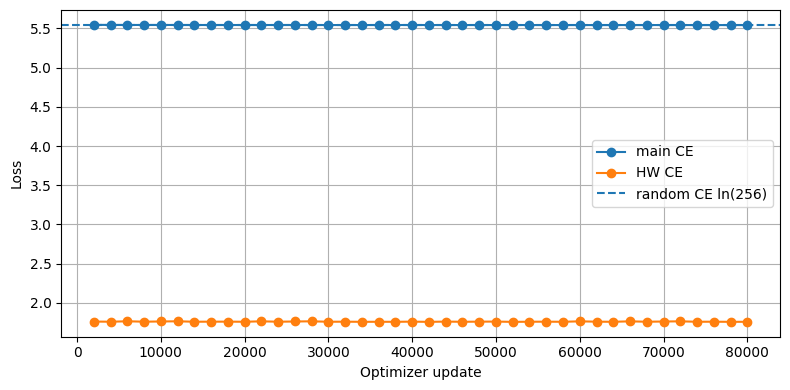

In [11]:
# ============================================================
model.train()
train_iter = infinite_loader(train_loader)

loss_window = []
main_window = []
hw_window = []
bit_window = []
acc_window = []
grad_window = []

pbar = tqdm(range(start_step + 1, TRAIN_STEPS + 1), desc="Training updates")

for step in pbar:
    lr = set_lr(step)
    optimizer.zero_grad(set_to_none=True)

    update_loss = 0.0
    update_main = 0.0
    update_hw = 0.0
    update_bit = 0.0
    update_acc = 0.0

    for micro_step in range(GRAD_ACCUM_STEPS):
        traces, labels, hw_labels, bit_labels = next(train_iter)
        traces = traces.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        hw_labels = hw_labels.to(DEVICE, non_blocking=True)
        bit_labels = bit_labels.to(DEVICE, non_blocking=True)

        with torch.amp.autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
            outputs = model(traces, return_aux=True)
            main_loss = criterion_cls(outputs["logits"], labels)
            hw_loss = criterion_hw(outputs["hw_logits"], hw_labels)
            bit_loss = criterion_bits(outputs["bit_logits"], bit_labels)
            loss = main_loss + HW_AUX_WEIGHT * hw_loss + BIT_AUX_WEIGHT * bit_loss
            loss_for_backward = loss / GRAD_ACCUM_STEPS

        if not torch.isfinite(loss):
            raise RuntimeError(f"Non-finite loss at step {step}: {loss.item()}")

        scaler.scale(loss_for_backward).backward()

        with torch.no_grad():
            acc = (outputs["logits"].argmax(dim=1) == labels).float().mean().item()

        update_loss += float(loss.item())
        update_main += float(main_loss.item())
        update_hw += float(hw_loss.item())
        update_bit += float(bit_loss.item())
        update_acc += float(acc)

    scaler.unscale_(optimizer)
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    scaler.step(optimizer)
    scaler.update()

    update_loss /= GRAD_ACCUM_STEPS
    update_main /= GRAD_ACCUM_STEPS
    update_hw /= GRAD_ACCUM_STEPS
    update_bit /= GRAD_ACCUM_STEPS
    update_acc /= GRAD_ACCUM_STEPS

    loss_window.append(update_loss)
    main_window.append(update_main)
    hw_window.append(update_hw)
    bit_window.append(update_bit)
    acc_window.append(update_acc)
    grad_window.append(float(grad_norm))

    if len(loss_window) > 200:
        loss_window.pop(0); main_window.pop(0); hw_window.pop(0); bit_window.pop(0); acc_window.pop(0); grad_window.pop(0)

    if step % 100 == 0:
        pbar.set_postfix({
            "main": np.mean(main_window),
            "hw": np.mean(hw_window),
            "acc": np.mean(acc_window),
            "lr": lr,
            "gnorm": np.mean(grad_window),
            "samples_M": step * EFFECTIVE_BATCH_SIZE / 1e6,
        })

    if step % SAVE_EVERY_STEPS == 0 or step == TRAIN_STEPS:
        row = {
            "step": int(step),
            "samples_seen": int(step * EFFECTIVE_BATCH_SIZE),
            "loss200": float(np.mean(loss_window)),
            "main_loss200": float(np.mean(main_window)),
            "hw_loss200": float(np.mean(hw_window)),
            "bit_loss200": float(np.mean(bit_window)),
            "acc200": float(np.mean(acc_window)),
            "lr": float(lr),
            "grad_norm200": float(np.mean(grad_window)),
            "train_batch_size": int(TRAIN_BATCH_SIZE),
            "grad_accum_steps": int(GRAD_ACCUM_STEPS),
            "effective_batch_size": int(EFFECTIVE_BATCH_SIZE),
        }
        history.append(row)
        pd.DataFrame(history).to_csv(RESULT_DIR / "training_history.csv", index=False)
        save_checkpoint(step, "last.pt")
        save_checkpoint(step, f"step_{step}.pt")
        print("Saved checkpoint:", row)

hist = pd.DataFrame(history)
display(hist.tail(20))

plt.figure(figsize=(8, 4))
plt.plot(hist["step"], hist["main_loss200"], marker="o", label="main CE")
plt.plot(hist["step"], hist["hw_loss200"], marker="o", label="HW CE")
plt.axhline(np.log(256), linestyle="--", label="random CE ln(256)")
plt.xlabel("Optimizer update")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "training_loss.png", dpi=180)
plt.show()

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Checkpoints from step 70000 onward:
 - step_70000.pt
 - step_72000.pt
 - step_74000.pt
 - step_76000.pt
 - step_78000.pt
 - step_80000.pt

Evaluating checkpoint: step_70000.pt


Predict step_70000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/30 [00:00<?, ?it/s]

{'checkpoint': 'step_70000.pt', 'step': 70000, 'attack_acc': 0.0038, 'single_final_rank': 241, 'single_min_rank': 60, 'single_traces_to_rank0': None, 'ge_final': 203.93333333333334, 'ge_min': 118.26666666666667, 'traces_to_ge_below_1': None}

Evaluating checkpoint: step_72000.pt


Predict step_72000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

...

{'checkpoint': 'step_78000.pt', 'step': 78000, 'attack_acc': 0.0038, 'single_final_rank': 240, 'single_min_rank': 69, 'single_traces_to_rank0': None, 'ge_final': 204.13333333333333, 'ge_min': 117.8, 'traces_to_ge_below_1': None}

Evaluating checkpoint: step_80000.pt


Predict step_80000.pt:   0%|          | 0/79 [00:00<?, ?it/s]

GE repeats:   0%|          | 0/30 [00:00<?, ?it/s]

{'checkpoint': 'step_80000.pt', 'step': 80000, 'attack_acc': 0.0038, 'single_final_rank': 240, 'single_min_rank': 67, 'single_traces_to_rank0': None, 'ge_final': 204.63333333333333, 'ge_min': 118.7, 'traces_to_ge_below_1': None}


,checkpoint,step,attack_acc,single_final_rank,single_min_rank,single_traces_to_rank0,ge_final,ge_min,traces_to_ge_below_1
0,step_70000.pt,70000,0.0038,241,60,None,203.933333,118.266667,None
1,step_72000.pt,72000,0.0038,239,66,None,204.000000,118.066667,None
2,step_74000.pt,74000,0.0038,240,74,None,204.533333,118.566667,None
3,step_76000.pt,76000,0.0038,240,67,None,203.700000,118.666667,None
4,step_78000.pt,78000,0.0038,240,69,None,204.133333,117.800000,None
5,step_80000.pt,80000,0.0038,240,67,None,204.633333,118.700000,None


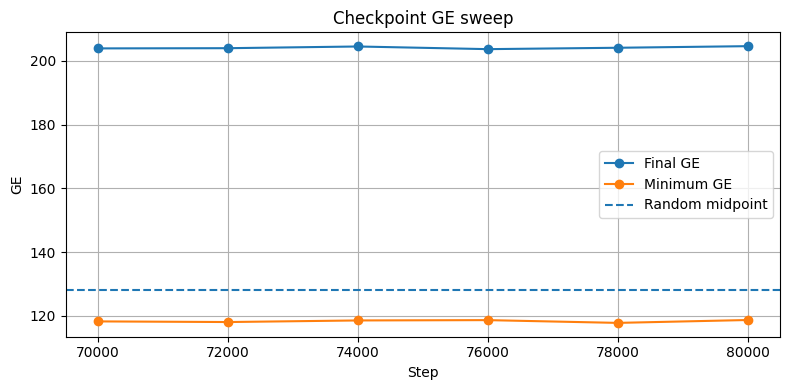

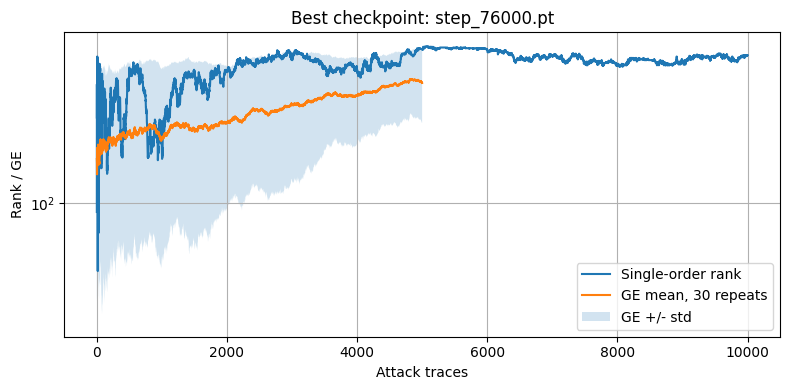

{
  "model_tag": "hdlstm_desync100_standard_d128_h64_w50_bs128x2_norm-global_aug0",
  "dataset_tag": "desync100",
  "ascad_path": "/kaggle/input/datasets/govindgopa/ascad-dataset/ASCAD_desync100.h5",
  "true_key": 224,
  "best_checkpoint": {
    "checkpoint": "step_76000.pt",
    "step": 76000,
    "attack_acc": 0.0038,
    "single_final_rank": 240,
    "single_min_rank": 67,
    "single_traces_to_rank0": null,
    "ge_final": 203.7,
    "ge_min": 118.66666666666667,
    "traces_to_ge_below_1": null
  },
  "num_params": 2377489,
  "norm_mode": "global",
  "aug_shift": 0,
  "effective_batch_size": 256,
  "hw_aux_weight": 0.2,
  "bit_aux_weight": 0.05
}


In [12]:
# ============================================================
@torch.no_grad()
def predict_logits(model, loader, desc="Predict"):
    model.eval()
    all_logits = []
    all_labels = []
    for batch in tqdm(loader, desc=desc, leave=False):
        traces, labels = batch[0], batch[1]
        traces = traces.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
            logits = model(traces, return_aux=False)
        all_logits.append(logits.float().cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_logits, axis=0), np.concatenate(all_labels, axis=0)


def checkpoint_sort_key(path):
    m = re.search(r"step_(\d+)", path.name)
    if m:
        return int(m.group(1))
    if path.name == "last.pt":
        return 10**12
    return -1


def load_checkpoint_for_eval(path):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model"], strict=True)
    return int(ckpt.get("step", checkpoint_sort_key(path)))


def evaluate_checkpoint(path, n_repeats=N_RANK_REPEATS, n_traces=ATTACK_TRACES_FOR_GE):
    step = load_checkpoint_for_eval(path)
    logits, labels = predict_logits(model, attack_loader, desc=f"Predict {path.name}")
    log_probs = stable_log_softmax_np(logits)

    pred = logits.argmax(axis=1)
    attack_acc = float(np.mean(pred == y_attack))

    single_curve = rank_curve_from_log_probs(log_probs, attack_plain, ATTACK_TRUE_KEY)
    ge_mean, ge_std, ge_curves = guessing_entropy_from_log_probs(
        log_probs,
        attack_plain,
        ATTACK_TRUE_KEY,
        n_traces=min(n_traces, len(log_probs)),
        n_repeats=n_repeats,
        seed=SEED + 777,
    )
    metrics = metrics_from_ge(single_curve, ge_mean)
    row = {
        "checkpoint": path.name,
        "step": int(step),
        "attack_acc": attack_acc,
        **metrics,
    }
    return row, single_curve, ge_mean, ge_std, logits

MIN_EVAL_STEP = 70000

ckpt_paths = sorted(
    [
        p for p in CKPT_DIR.glob("step_*.pt")
        if checkpoint_sort_key(p) >= MIN_EVAL_STEP
    ],
    key=checkpoint_sort_key,
)

# Optional fallback: include last.pt only if it is also >= MIN_EVAL_STEP.
if len(ckpt_paths) == 0 and (CKPT_DIR / "last.pt").exists():
    last_ckpt = torch.load(
        CKPT_DIR / "last.pt",
        map_location="cpu",
        weights_only=False,
    )

    last_step = int(last_ckpt.get("step", -1))

    if last_step >= MIN_EVAL_STEP:
        ckpt_paths = [CKPT_DIR / "last.pt"]
    else:
        raise FileNotFoundError(
            f"No checkpoints found at or after step {MIN_EVAL_STEP}. "
            f"last.pt is only step {last_step}."
        )

print(f"Checkpoints from step {MIN_EVAL_STEP} onward:")
for p in ckpt_paths:
    print(" -", p.name)

if len(ckpt_paths) == 0:
    raise FileNotFoundError(
        f"No checkpoints found at or after step {MIN_EVAL_STEP} in {CKPT_DIR}"
    )

sweep_rows = []
best = None

for p in ckpt_paths:
    print("\nEvaluating checkpoint:", p.name)
    row, single_curve, ge_mean, ge_std, logits = evaluate_checkpoint(p)
    sweep_rows.append(row)
    print(row)
    if best is None or row["ge_final"] < best["row"]["ge_final"]:
        best = {"row": row, "path": p, "single_curve": single_curve, "ge_mean": ge_mean, "ge_std": ge_std, "logits": logits}

sweep_df = pd.DataFrame(sweep_rows).sort_values("step")
display(sweep_df)
sweep_df.to_csv(RESULT_DIR / "checkpoint_rank_ge_sweep.csv", index=False)

plt.figure(figsize=(8, 4))
plt.plot(sweep_df["step"], sweep_df["ge_final"], marker="o", label="Final GE")
plt.plot(sweep_df["step"], sweep_df["ge_min"], marker="o", label="Minimum GE")
plt.axhline(128, linestyle="--", label="Random midpoint")
plt.xlabel("Step")
plt.ylabel("GE")
plt.title("Checkpoint GE sweep")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "checkpoint_ge_sweep.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(best["single_curve"], label="Single-order rank")
plt.plot(best["ge_mean"], label=f"GE mean, {N_RANK_REPEATS} repeats")
plt.fill_between(
    np.arange(len(best["ge_mean"])),
    np.maximum(best["ge_mean"] - best["ge_std"], 0),
    best["ge_mean"] + best["ge_std"],
    alpha=0.2,
    label="GE +/- std",
)
plt.xlabel("Attack traces")
plt.ylabel("Rank / GE")
plt.yscale("symlog", linthresh=1)
plt.title(f"Best checkpoint: {best['path'].name}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(RESULT_DIR / "best_rank_ge_curve.png", dpi=180)
plt.show()

summary = {
    "model_tag": MODEL_TAG,
    "dataset_tag": DATASET_TAG,
    "ascad_path": ASCAD_PATH,
    "true_key": int(ATTACK_TRUE_KEY),
    "best_checkpoint": best["row"],
    "num_params": int(num_params),
    "norm_mode": NORM_MODE,
    "aug_shift": int(AUG_SHIFT),
    "effective_batch_size": int(EFFECTIVE_BATCH_SIZE),
    "hw_aux_weight": float(HW_AUX_WEIGHT),
    "bit_aux_weight": float(BIT_AUX_WEIGHT),
}
with open(RESULT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))
